In [1]:
# ========================================
# 1. Librerías
# ========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# ========================================
# 2. Cargar datos
# ========================================
df = pd.read_csv("alzheimers_disease_data.csv")

df["AD"]    = df["Diagnosis"] == 1
df["No-AD"] = df["Diagnosis"] == 0

cols = [
    'MMSE', 'FunctionalAssessment',
    'MemoryComplaints', 'BehavioralProblems', 'ADL', 
     'FamilyHistoryAlzheimers',
    'Diagnosis', 'AD', 'No-AD'
]
df = df[cols]

X = df.drop(columns=["AD", "No-AD", "Diagnosis"])
y = df["AD"]

# Escalado opcional (Random Forest no lo requiere, pero lo dejamos para consistencia)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

Importancia de variables:
                    Feature  Importance
1     FunctionalAssessment    0.288187
4                      ADL    0.263342
0                     MMSE    0.228604
2         MemoryComplaints    0.130639
3       BehavioralProblems    0.082148
5  FamilyHistoryAlzheimers    0.007080


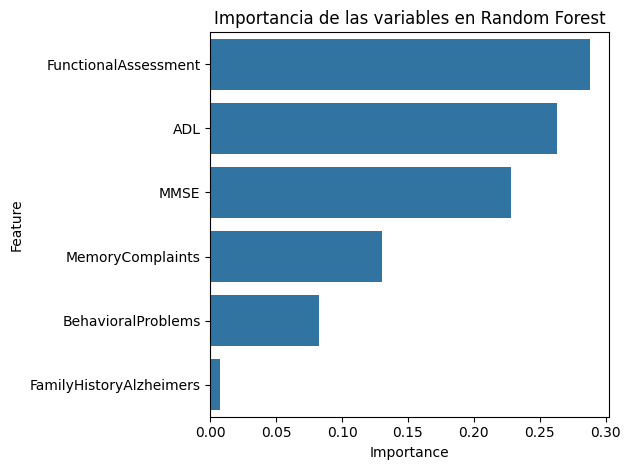

In [3]:
# ========================================
# 3. Entrenar Random Forest inicial
# ========================================
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# Importancias
importances = modelo_rf.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False)

print("Importancia de variables:\n", feature_df)

# Plot
sns.barplot(x="Importance", y="Feature", data=feature_df)
plt.title("Importancia de las variables en Random Forest")
plt.tight_layout()
plt.show()

In [4]:
# ========================================
# 4. Selección de variables (descartar muy poco importantes)
# ========================================
selected_features = feature_df[feature_df["Importance"] > 0.01]["Feature"].tolist()
print("Variables seleccionadas:", selected_features)

X_selected = df[selected_features]
X_scaled = scaler.fit_transform(X_selected)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

Variables seleccionadas: ['FunctionalAssessment', 'ADL', 'MMSE', 'MemoryComplaints', 'BehavioralProblems']


In [5]:
# ========================================
# 5. GridSearchCV para ajustar hiperparámetros
# ========================================
param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Mejores parámetros:", grid.best_params_)
print("Mejor AUC (CV):", grid.best_score_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Mejores parámetros: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Mejor AUC (CV): 0.9507443256178639


In [7]:
# ========================================
# 6. Evaluación en test
# ========================================
y_probs = best_rf.predict_proba(X_test)[:, 1]
y_pred_default = (y_probs >= 0.5).astype(int)

print("\n--- Rendimiento con umbral 0.5 ---")
print("Accuracy:", accuracy_score(y_test, y_pred_default))
print("AUC:", roc_auc_score(y_test, y_probs))
print(classification_report(y_test, y_pred_default))


--- Rendimiento con umbral 0.5 ---
Accuracy: 0.951937984496124
AUC: 0.946569060541041
              precision    recall  f1-score   support

       False       0.96      0.97      0.96       417
        True       0.95      0.92      0.93       228

    accuracy                           0.95       645
   macro avg       0.95      0.94      0.95       645
weighted avg       0.95      0.95      0.95       645



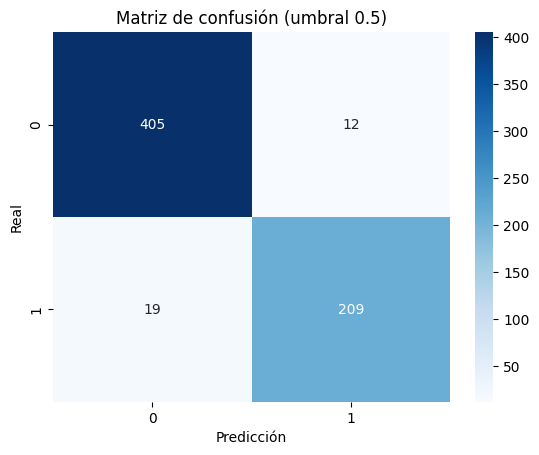

In [8]:
sns.heatmap(confusion_matrix(y_test, y_pred_default),
            annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión (umbral 0.5)")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.show()

Umbral óptimo según Youden: 0.345861111111111

--- Rendimiento con umbral óptimo ---
Accuracy: 0.9503875968992248
AUC: 0.946569060541041
              precision    recall  f1-score   support

       False       0.96      0.96      0.96       417
        True       0.93      0.93      0.93       228

    accuracy                           0.95       645
   macro avg       0.94      0.95      0.95       645
weighted avg       0.95      0.95      0.95       645



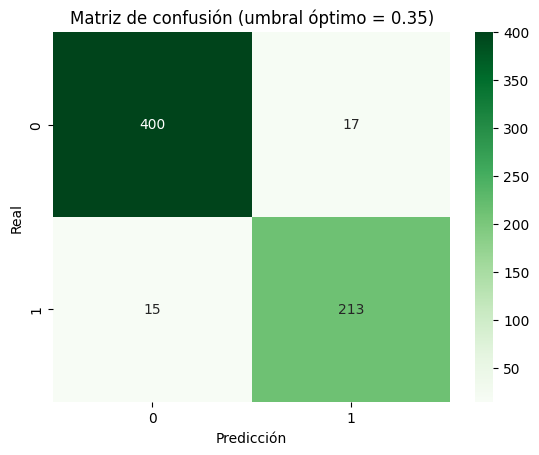

In [7]:
# ========================================
# 7. Ajuste de umbral óptimo
# ========================================
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
optimal_idx = np.argmax(tpr - fpr)  # índice de Youden
optimal_threshold = thresholds[optimal_idx]

print("Umbral óptimo según Youden:", optimal_threshold)

y_pred_opt = (y_probs >= optimal_threshold).astype(int)

print("\n--- Rendimiento con umbral óptimo ---")
print("Accuracy:", accuracy_score(y_test, y_pred_opt))
print("AUC:", roc_auc_score(y_test, y_probs))
print(classification_report(y_test, y_pred_opt))

sns.heatmap(confusion_matrix(y_test, y_pred_opt),
            annot=True, fmt="d", cmap="Greens")
plt.title(f"Matriz de confusión (umbral óptimo = {optimal_threshold:.2f})")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.show()

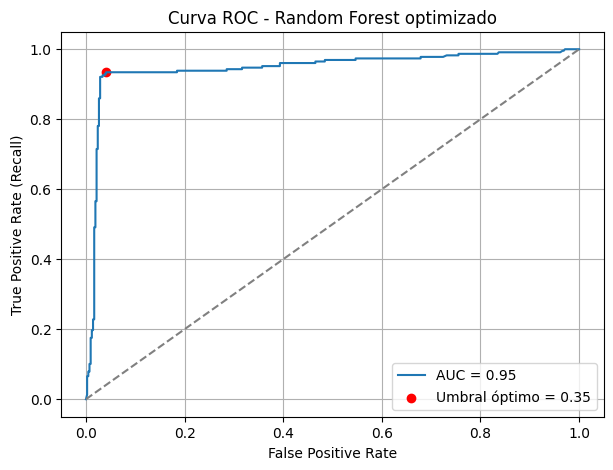

In [8]:
# ========================================
# 8. Curva ROC
# ========================================
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_probs):.2f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color="red",
            label=f"Umbral óptimo = {optimal_threshold:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Curva ROC - Random Forest optimizado")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models

# ======================
# 1) Cargar dataset
# ======================
df = pd.read_csv("alzheimers_disease_data.csv")

# Definir variables predictoras y target
X = df.drop(columns=["Diagnosis", "DoctorInCharge", "PatientID"])  # quita columnas no predictivas
y = df["Diagnosis"]  # 0 = No Alzheimer, 1 = Alzheimer

# Escalar numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ======================
# 2) MLP Tabular
# ======================
def build_mlp(input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    out = layers.Dense(1, activation="sigmoid")(x)  # salida binaria
    model = models.Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

mlp = build_mlp(X_train.shape[1])

# Entrenamiento
history = mlp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30, batch_size=32, verbose=1
)

# ======================
# 3) Evaluación
# ======================
y_pred_prob = mlp.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))


Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.6562 - loss: 0.6149 - val_accuracy: 0.7705 - val_loss: 0.5162
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7852 - loss: 0.4791 - val_accuracy: 0.8171 - val_loss: 0.4288
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8172 - loss: 0.4128 - val_accuracy: 0.8295 - val_loss: 0.4048
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8338 - loss: 0.3808 - val_accuracy: 0.8372 - val_loss: 0.3952
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8378 - loss: 0.3631 - val_accuracy: 0.8419 - val_loss: 0.3937
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8517 - loss: 0.3557 - val_accuracy: 0.8372 - val_loss: 0.3903
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8451 - loss: 0.3491 - val_accuracy: 0.8403 - val_loss: 0.3932
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8630 - loss: 0.3266 - val_accuracy: 0.8403 - val_loss

In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# ======================
# 1) Cargar dataset
# ======================
df = pd.read_csv("alzheimers_disease_data.csv")

X = df.drop(columns=["Diagnosis", "DoctorInCharge", "PatientID"])
y = df["Diagnosis"]

# Escalar numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ======================
# 2) MLP Mejorado
# ======================
def build_mlp_improved(input_dim):
    inp = layers.Input(shape=(input_dim,))
    
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    
    out = layers.Dense(1, activation="sigmoid")(x)
    
    model = models.Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

mlp = build_mlp_improved(X_train.shape[1])

# ======================
# 3) Callbacks y class weights
# ======================
# Class weights para balancear
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class weights:", class_weights)

# Early stopping
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

# ======================
# 4) Entrenamiento
# ======================
history = mlp.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100, batch_size=32, verbose=1,
    class_weight=class_weights,
    callbacks=[early_stop]
)

# ======================
# 5) Evaluación
# ======================
y_pred_prob = mlp.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_prob))


Class weights: {0: 0.7736625514403292, 1: 1.413533834586466}
Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5851 - loss: 0.8109 - val_accuracy: 0.7225 - val_loss: 0.6543
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7254 - loss: 0.5657 - val_accuracy: 0.7643 - val_loss: 0.5895
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7586 - loss: 0.5358 - val_accuracy: 0.8109 - val_loss: 0.5282
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7806 - loss: 0.4892 - val_accuracy: 0.8233 - val_loss: 0.4887
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7999 - loss: 0.4646 - val_accuracy: 0.8202 - val_loss: 0.4738
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8225 - loss: 0.4434 - val_accuracy: 0.8202 - val_loss: 0.4690
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8311 - loss: 0.4200 - val_accuracy: 0.8233 - val_loss: 0.4661
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import xgboost as xgb

# ======================
# 1) Cargar dataset
# ======================
df = pd.read_csv("alzheimers_disease_data.csv")

X = df.drop(columns=["Diagnosis", "DoctorInCharge", "PatientID"])
y = df["Diagnosis"]

# Escalar numéricas (XGBoost no lo necesita estrictamente, pero puede ayudar en convergencia)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# ======================
# 2) Modelo XGBoost
# ======================
xgb_model = xgb.XGBClassifier(
    n_estimators=1200,       # más árboles
    learning_rate=0.01,      # más bajo → menos overfitting
    max_depth=6,             # un poco más de complejidad
    min_child_weight=2,      # evita árboles muy pequeños
    subsample=0.9,           # bagging
    colsample_bytree=0.9,    # random feature sampling
    gamma=0.1,               # penaliza divisiones débiles
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=2.0,          # más penalización L2
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]), # balance clases
    random_state=42,
    n_jobs=-1,
    eval_metric="auc"
)


xgb_model.fit(X_train, y_train)

# ======================
# 3) Predicciones
# ======================
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

# AUC
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC:", auc)

# ======================
# 4) Umbral óptimo (Youden J)
# ======================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]
print("Umbral óptimo según Youden:", best_threshold)

# Predicciones con umbral óptimo
y_pred_opt = (y_pred_prob >= best_threshold).astype(int)

# Reporte
print("\n--- Rendimiento con umbral óptimo ---")
print("Accuracy:", (y_pred_opt == y_test).mean())
print(classification_report(y_test, y_pred_opt))


ROC AUC: 0.949640287769784
Umbral óptimo según Youden: 0.58036363

--- Rendimiento con umbral óptimo ---
Accuracy: 0.9534883720930233
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       417
           1       0.95      0.92      0.93       228

    accuracy                           0.95       645
   macro avg       0.95      0.95      0.95       645
weighted avg       0.95      0.95      0.95       645



In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(xgb_model, X_scaled, y, cv=cv, scoring="roc_auc", n_jobs=-1)

print("AUC CV scores:", cv_auc)
print("Mean AUC CV:", cv_auc.mean())


AUC CV scores: [0.95742616 0.95020825 0.9415231  0.95586426 0.95394737]
Mean AUC CV: 0.9517938280954183


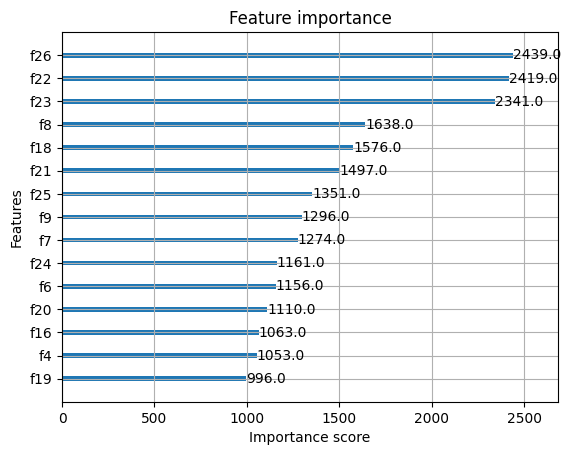

In [13]:
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model, max_num_features=15)
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [300, 500, 800],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "gamma": [0, 0.5, 1]
}

xgb_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)

grid = GridSearchCV(
    estimator=xgb_clf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Mejores parámetros:", grid.best_params_)
print("Mejor AUC CV:", grid.best_score_)


Fitting 5 folds for each of 2187 candidates, totalling 10935 fits


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
import xgboost as xgb

# ======================
# 1) Definir la función objetivo
# ======================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 1200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 6),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 2),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "auc",
        "use_label_encoder": False
    }
    
    model = xgb.XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc = cross_val_score(model, X_scaled, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()
    return auc

# ======================
# 2) Crear y ejecutar el estudio
# ======================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, n_jobs=-1)  # puedes aumentar n_trials a 200+

# ======================
# 3) Resultados
# ======================
print("Mejores parámetros:", study.best_trial.params)
print("Mejor AUC CV:", study.best_value)

# ======================
# 4) Entrenar modelo final con los mejores parámetros
# ======================
best_params = study.best_trial.params
xgb_best = xgb.XGBClassifier(**best_params, eval_metric="auc", use_label_encoder=False)
xgb_best.fit(X_train, y_train)

# Predicciones
y_pred_prob = xgb_best.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
print("AUC en test:", auc)


In [ ]:
# =====================================
# 1) Librerías
# =====================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# =====================================
# 2) Cargar dataset
# =====================================
df = pd.read_csv("alzheimers_disease_data.csv")

X = df.drop(columns=["Diagnosis", "DoctorInCharge", "PatientID"])
y = df["Diagnosis"]

# Escalado (opcional, algunos modelos lo ignoran)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# =====================================
# 3) Modelos base
# =====================================
xgb_clf = xgb.XGBClassifier(
    n_estimators=800, learning_rate=0.02, max_depth=6,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42, eval_metric="logloss", use_label_encoder=False
)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=800, learning_rate=0.02, max_depth=-1,
    subsample=0.9, colsample_bytree=0.9,
    random_state=42
)

cat_clf = CatBoostClassifier(
    iterations=800, learning_rate=0.02, depth=6,
    verbose=0, random_seed=42
)

rf_clf = RandomForestClassifier(
    n_estimators=500, max_depth=10, random_state=42, n_jobs=-1
)

# =====================================
# 4) Stacking Ensemble
# =====================================
estimators = [
    ("xgb", xgb_clf),
    ("lgb", lgb_clf),
    ("cat", cat_clf),
    ("rf", rf_clf)
]

stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, n_jobs=-1, passthrough=False
)

# =====================================
# 5) Entrenamiento
# =====================================
stack_clf.fit(X_train, y_train)

# =====================================
# 6) Evaluación
# =====================================
y_pred_prob = stack_clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC (stacking):", auc)

y_pred = (y_pred_prob > 0.5).astype(int)
print(classification_report(y_test, y_pred))
